### Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

## Descriptive Analytics for Numerical Columns

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
sales_data= pd.read_csv('sales_data_with_discounts.csv')
sales_data.head(5)

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [32]:
sales_data.tail(5)

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174
449,15-04-2021,Thursday,L10,C,1,Lifestyle,Jeera,M-Shoes,3100,3100,15.333300,475.332295,2624.667705


### Identify numerical columns in the dataset.

In [37]:
# Select only numerical columns
numerical_columns=sales_data.select_dtypes(['int64','float64'])
#Display numerical Columns names
print('Numerical Columns:')
numerical_columns.columns

Numerical Columns:


Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [23]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [22]:
data.isna().sum() # . Missing Values Check

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [24]:
data.duplicated().sum() # checking duplicate value 

np.int64(0)

In [38]:
# Create an empty dictionary to store results
stats_summary={}
for column in numerical_columns.columns:
    stats_summary[column] = {
        "Mean": numerical_columns[column].mean(),
        "Median": numerical_columns[column].median(),
        "Mode": numerical_columns[column].mode()[0], 
        "Standard Deviation": numerical_columns[column].std()
    }
# Convert dictionary to DataFrame for better readability
stats_df = pd.DataFrame(stats_summary)

# Display results
stats_df

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
Mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
Median,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
Mode,3.000000,400.000000,24300.000000,5.007822,69.177942,326.974801
Standard Deviation,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624


### Data Visualization

#### ●	Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.
##### ●	Histograms:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.

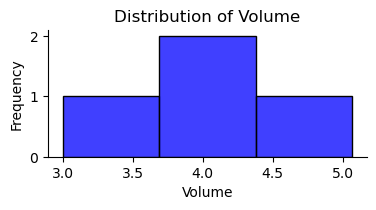

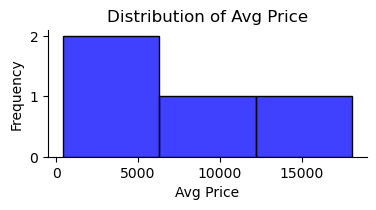

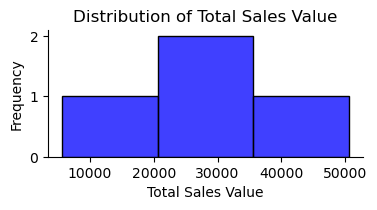

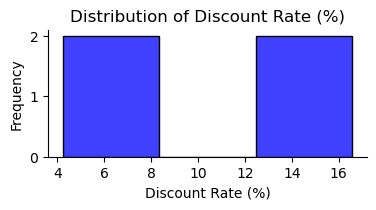

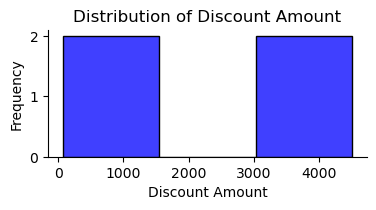

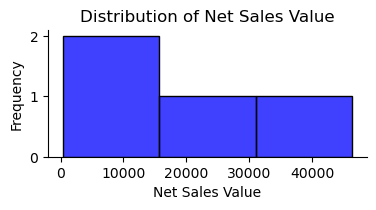

In [41]:
#Identify Numerical columns in the dataset.
numerical_columns = [
    "Volume",
    "Avg Price",
    "Total Sales Value",
    "Discount Rate (%)",
    "Discount Amount",
    "Net Sales Value"
]

# Plot histograms for each numerical column.
for column in numerical_columns:
    sns.displot(stats_df,x=stats_df[column],kind='hist',height=2,aspect=2,color='blue')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [42]:
sales_data[numerical_columns].skew()

Volume               2.731724
Avg Price            1.908873
Total Sales Value    1.534729
Discount Rate (%)   -1.062294
Discount Amount      1.913038
Net Sales Value      1.540822
dtype: float64

#### Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences:

- Most numerical variables such as Volume, Avg Price, Total Sales Value, Discount Amount, and Net Sales Value are positively skewed, indicating that a few high-value transactions significantly influence overall sales.

- Discount Rate (%) is negatively skewed, suggesting higher discount percentages are more common.

- The strong positive skewness in Volume indicates possible high-value outliers.

#### ●	Box Plots:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.

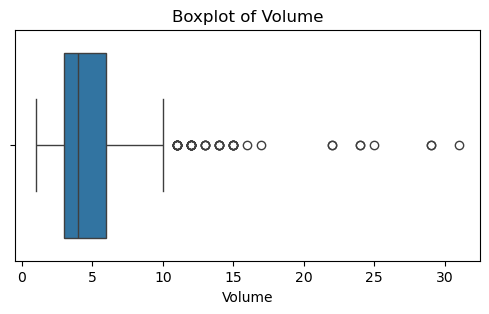

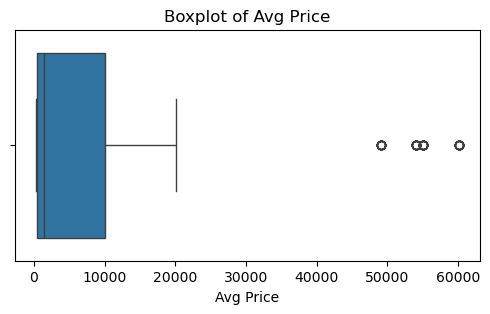

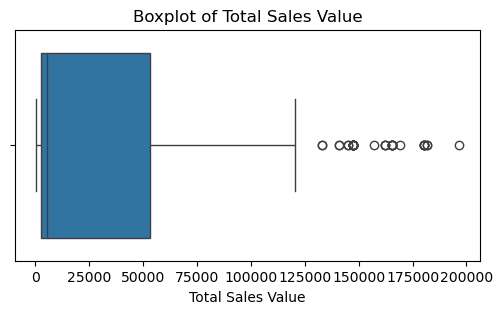

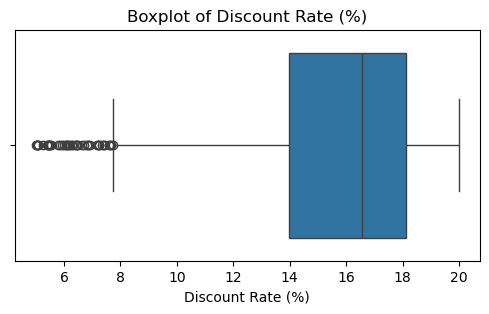

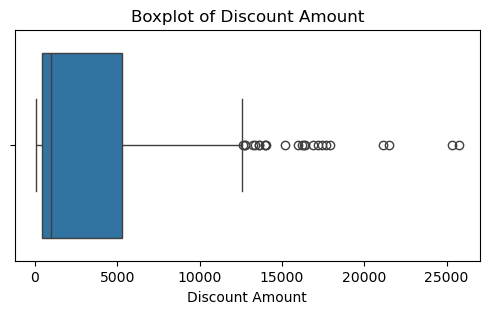

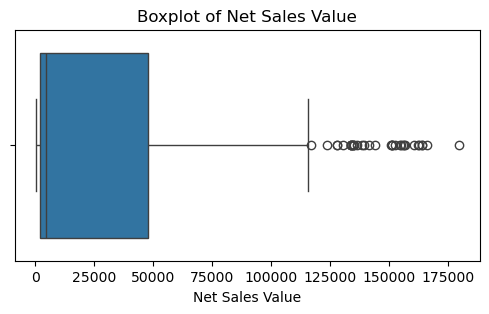

In [46]:
#Create boxplots for numerical variables to identify outliers and the interquartile range.
for column in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=sales_data[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

#### Discuss any findings, such as extreme values or unusual distributions

- Most numerical variables such as Volume, Avg Price, Total Sales Value, Discount Amount, and Net Sales Value are positively skewed, indicating that a few high-value transactions significantly influence overall sales.

- Discount Rate (%) is negatively skewed, suggesting higher discount percentages are more common.

- The strong positive skewness in Volume indicates possible high-value outliers.

#### ●	Bar Chart Analysis for Categorical Column:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.
	Analyze the distribution of categories and provide insights.

In [47]:
#identify categorical dataset
categorical_columns = sales_data.select_dtypes(include=['object']).columns
#display categorical dataset
categorical_columns

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

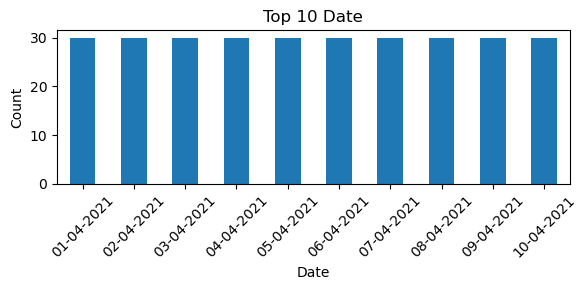

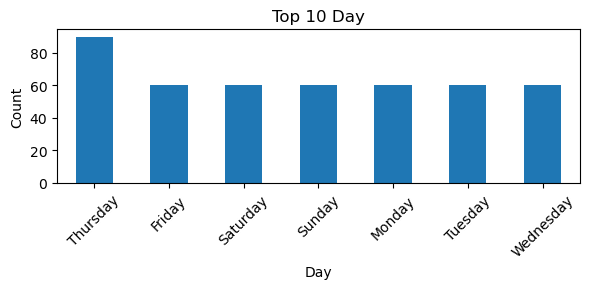

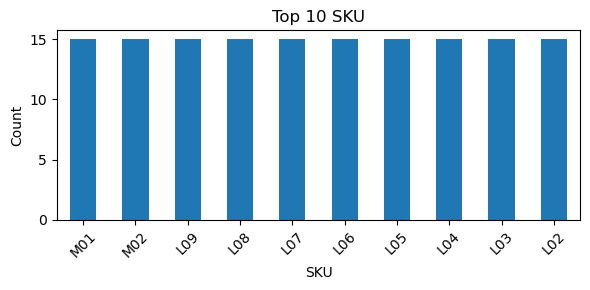

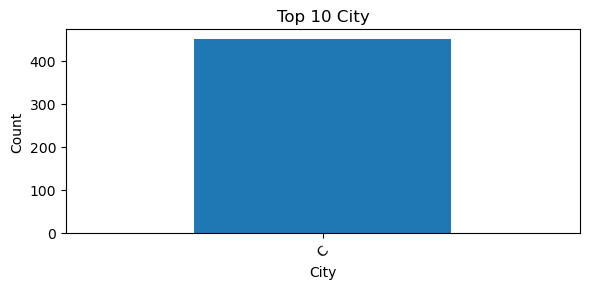

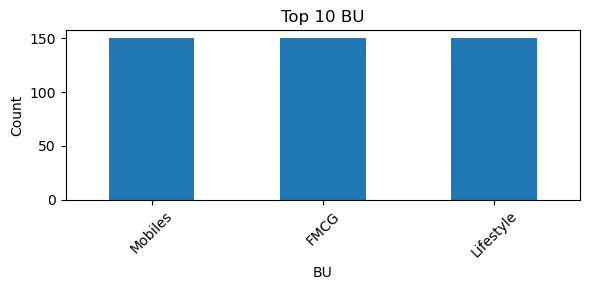

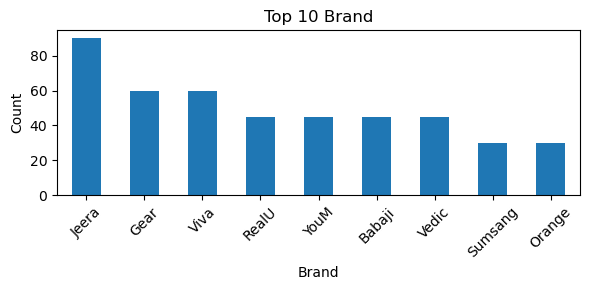

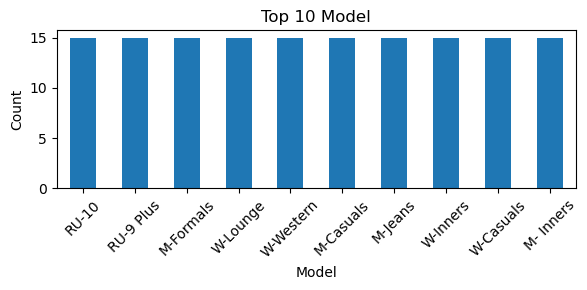

In [48]:
#Create bar charts to visualize the frequency or count of each category.
for column in categorical_columns:
    plt.figure(figsize=(6,3))
    
    top_values = sales_data[column].value_counts().nlargest(10)
    
    top_values.plot(kind='bar')
    
    plt.title(f"Top 10 {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Analyze the distribution of categories and provide insights


The bar charts show that the three business units (Mobiles, FMCG, Lifestyle) have nearly equal representation in the dataset.

Certain brands appear more frequently than others, indicating higher sales concentration in specific brands.

All SKUs and models have almost equal counts, suggesting balanced product distribution.

The City column contains only one category, meaning the dataset represents sales from a single city.

The Day distribution is fairly uniform, with slightly higher frequency on Thursday.

Overall, categorical data shows balanced distribution with minor dominance in specific brands and days.

## Conclusion

Key insights from the descriptive analytics:

Sales data is highly right-skewed due to premium products.

Discount rate is relatively consistent (~15–18%).

Strong outliers exist in price and revenue variables.

Dataset is clean (no missing values).

Data is ready for:

Feature engineering

Predictive modeling

Sales trend analysis